# <h1 style="color: blue"><strong>PREDIÇÃO DE MODELO DE CLASSIFICAÇÃO - ALGORITIMOS SUPERVISIONADOS</strong></h1>

## Modelo publico 'Breast Cancer Coimbra'

## Bibiotecas

In [334]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

## 1. Coleta de dados
- Separar os dados do dataset em uma variavel

In [335]:
df = pd.read_csv('./dataset/breast_cancer.csv', sep=',')

## 2. Analise Exploratória e Tratamento:
- Investigar valores nulos, tratar variáveis categóricas e balancear as classes caso haja assimetria entre os grupos.

### 2.1 Informações da tabela

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             175 non-null    int64  
 1   BMI             175 non-null    float64
 2   Glucose         175 non-null    int64  
 3   Insulin         175 non-null    float64
 4   HOMA            175 non-null    float64
 5   Leptin          175 non-null    float64
 6   Adiponectin     175 non-null    float64
 7   Resistin        175 non-null    float64
 8   MCP.1           175 non-null    float64
 9   Classification  175 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 13.8 KB


### 2.2 Verificar se há valores nulos e duplicados

#### 2.2.1 Verificação de dados nulos

In [337]:
df.isna().sum()

Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64

#### 2.2.2 Verificação de dados duplicados

In [338]:
dados_duplicados = df.duplicated().sum()
print(dados_duplicados)

59


#### 2.2.3 Removendo dados duplicados (se houver)

In [339]:
if dados_duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)

### 2.3 Verificar dados do dataset

In [340]:
# Mostra os 5 primeiros registros do dataset
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


### 2.4 Mostra uma analise dos dados como contagem do total de registros, media das colunas, valores minimos e máximos

In [341]:
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [342]:
df.groupby('Classification')['Glucose'].mean()

Classification
1     88.230769
2    105.562500
Name: Glucose, dtype: float64

### 2.5 Contagem das Classes e Analise Visual

#### 2.5.1 Contagem das classes

In [343]:
contagem_breast_cancer = df.groupby('Classification')['Classification'].count()
print(contagem_breast_cancer)

Classification
1    52
2    64
Name: Classification, dtype: int64


#### 2.5.2 Analise visual

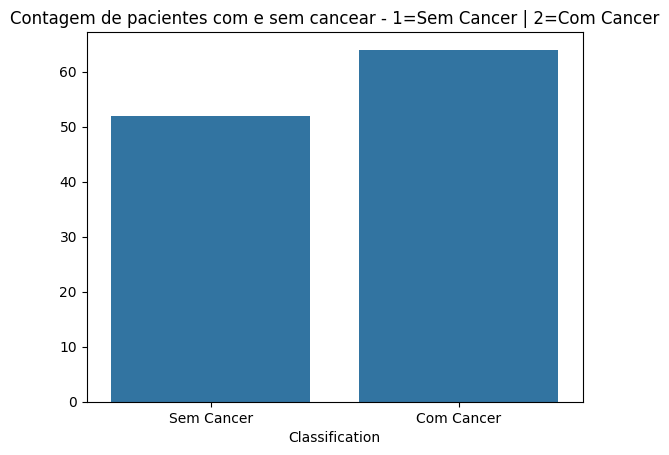

In [344]:
sns.barplot(x=contagem_breast_cancer.index, y=contagem_breast_cancer.values)
plt.title("Contagem de pacientes com e sem cancear - 1=Sem Cancer | 2=Com Cancer")
plt.xticks(ticks=['1','2'], labels=['Sem Cancer', 'Com Cancer'])
plt.show()

### 2.6 Separação de Features e Target

#### 2.6.1 Features

In [345]:
X_dados = df.drop(columns=['Classification'])
print(X_dados)

     Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  \
0     48  23.500000       70    2.707  0.467409   8.8071     9.702400   
1     83  20.690495       92    3.115  0.706897   8.8438     5.429285   
2     82  23.124670       91    4.498  1.009651  17.9393    22.432040   
3     68  21.367521       77    3.226  0.612725   9.8827     7.169560   
4     86  21.111111       92    3.549  0.805386   6.6994     4.819240   
..   ...        ...      ...      ...       ...      ...          ...   
111   45  26.850000       92    3.330  0.755688  54.6800    12.100000   
112   62  26.840000      100    4.530  1.117400  12.4500    21.420000   
113   65  32.050000       97    5.730  1.370998  61.4800    22.540000   
114   72  25.590000       82    2.820  0.570392  24.9600    33.750000   
115   86  27.180000      138   19.910  6.777364  90.2800    14.110000   

     Resistin    MCP.1  
0     7.99585  417.114  
1     4.06405  468.786  
2     9.27715  554.697  
3    12.76600  928.220 

#### 2.6.2 Target

In [346]:
y_dados = df['Classification']
print(y_dados)

0      1
1      1
2      1
3      1
4      1
      ..
111    2
112    2
113    2
114    2
115    2
Name: Classification, Length: 116, dtype: int64


### 2.7 Analise Visual

#### 2.7.1 Histograma

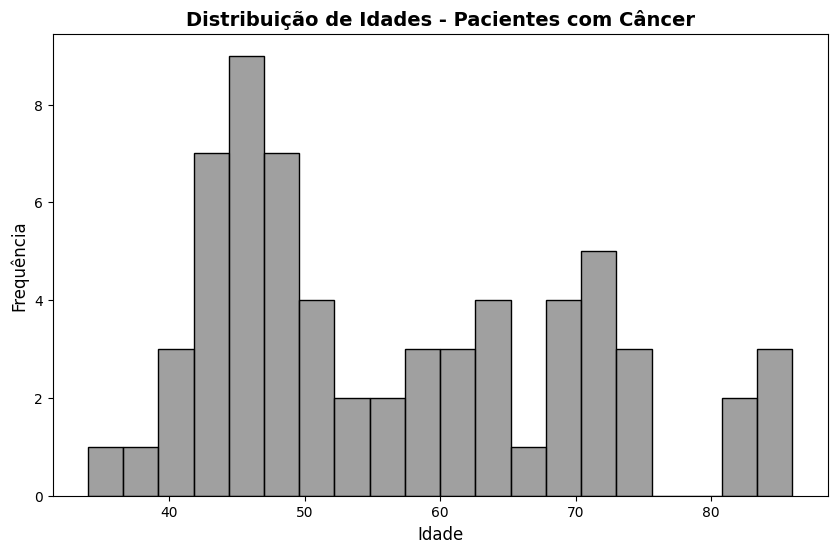

In [347]:
# %% [markdown]
# ### 2.7 Histograma da Distribuição de Idades - Pacientes com Câncer

# %%
import matplotlib.pyplot as plt
import seaborn as sns

# Filtra apenas os dados de pacientes diagnosticados com câncer (Classification == 2)
idades_com_cancer = df[df['Classification'] == 2]['Age']

# Configura a visualização do histograma
plt.figure(figsize=(10, 6))
sns.histplot(idades_com_cancer, bins=20, color='grey')

# Títulos e rótulos
plt.title("Distribuição de Idades - Pacientes com Câncer", fontsize=14, fontweight='bold')
plt.xlabel("Idade", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

# Exibe o gráfico
plt.show()

#### 2.7.2 Gráfico de dispersão

C:\Users\Moisas\AppData\Local\Temp\ipykernel_8676\2493951022.py:3: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.scatterplot(data=df,


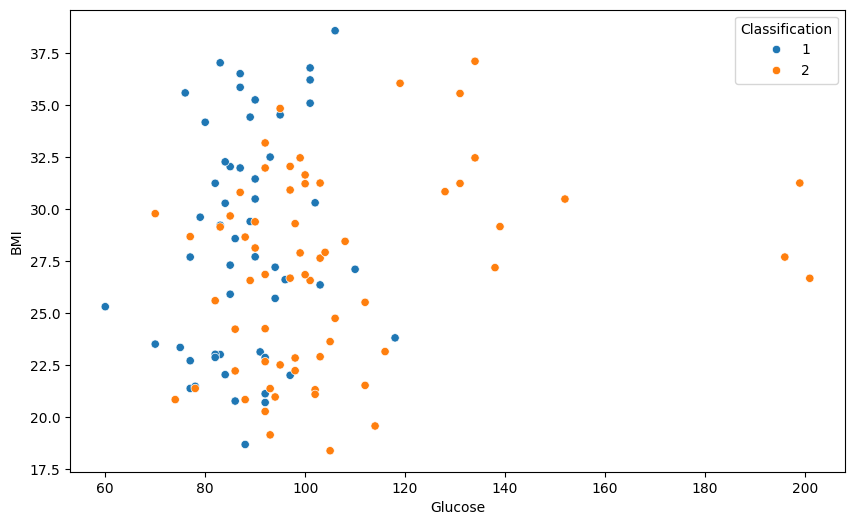

In [348]:
plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10')
sns.scatterplot(data=df,
                x='Glucose',
                y='BMI',
                hue='Classification',
                palette=palette)
plt.show()

#### 2.7.3 Gráfico de boxplot

C:\Users\Moisas\AppData\Local\Temp\ipykernel_8676\1282544407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Glucose', y='Classification', orient='h', data=df, palette='Set2')


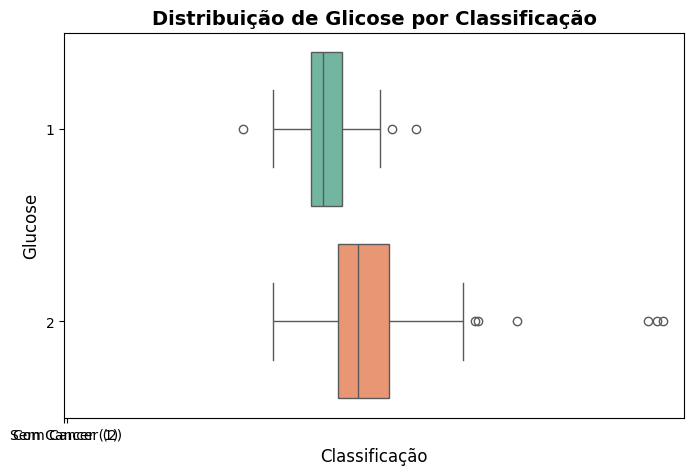

In [349]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Glucose', y='Classification', orient='h', data=df, palette='Set2')
plt.xticks(ticks=[0,1], labels=['Sem Cancer (1)', 'Com Cancer (2)'])
plt.title("Distribuição de Glicose por Classificação", fontsize=14, fontweight='bold')
plt.xlabel("Classificação", fontsize=12)
plt.ylabel("Glucose", fontsize=12)
plt.show()

### 3. Balanceamento de dados

In [350]:
def balanceamento_dados(X_dados, y_dados):
    X_arr = X_dados.to_numpy() if hasattr(X_dados, "to_numpy") else X_dados
    y_arr = y_dados.to_numpy() if hasattr(y_dados, "to_numpy") else y_dados
    
    undersample = RandomUnderSampler(random_state=42)
    X_under, y_under = undersample.fit_resample(X_arr, y_arr)
    
    tl = TomekLinks(sampling_strategy='all')
    X_under, y_under = tl.fit_resample(X_under, y_under)
    return X_under, y_under

X_dados_balanceados, y_dados_balanceados = balanceamento_dados(X_dados, y_dados)

In [351]:
print("Tamanho de X:", len(X_dados))
print("Tamanho de y:", len(y_dados))

Tamanho de X: 116
Tamanho de y: 116


#### 2.6.1 Verificando balanceamento

In [352]:
print(X_dados.shape)
print(f'Antes {X_dados.shape[0]}')
print(f'Depois {X_dados_balanceados.shape[0]}')

(116, 9)
Antes 116
Depois 90


## 3. Divisão dos Dados
- Separar a base em conjuntos de treino e teste (train_test_split) para evitar que o modelo decore as respostas.

### 3.1 Definição da função de Divisão (separ_treino_teste)

In [353]:
def separar_treino_teste(X_dados_balanceados, y_dados_balanceados):
    X_train, X_test, y_train, y_test = train_test_split(X_dados_balanceados, y_dados_balanceados, random_state=42, test_size=0.3)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = separar_treino_teste(X_dados_balanceados, y_dados_balanceados)

#### 3.1.1 Verificação das dimensões(shape)

In [354]:
print(X_train.shape)
print(X_test.shape)

(63, 9)
(27, 9)


## 4. Normalização ou Escalonamento
- Padronizar a escala das variáveis numéricas, etapa crítica para modelos sensíveis a distâncias ou gradientes.

In [355]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Escolha e Treinamento do Modelo (fit)

### 5.1 Arvode de Decisão (Decision Tree)

In [356]:
# Aprendizado Supervisionado
modelo = DecisionTreeClassifier(max_depth=10, random_state=0)


### 5.2 Treinamento do Modelo

In [357]:
modelo.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=10, random_state=0)

### 5.3 Predição do modelo

In [358]:
y_pred = modelo.predict(X_test_scaled)

### 5.4 Visualização da Arvore de Decisão

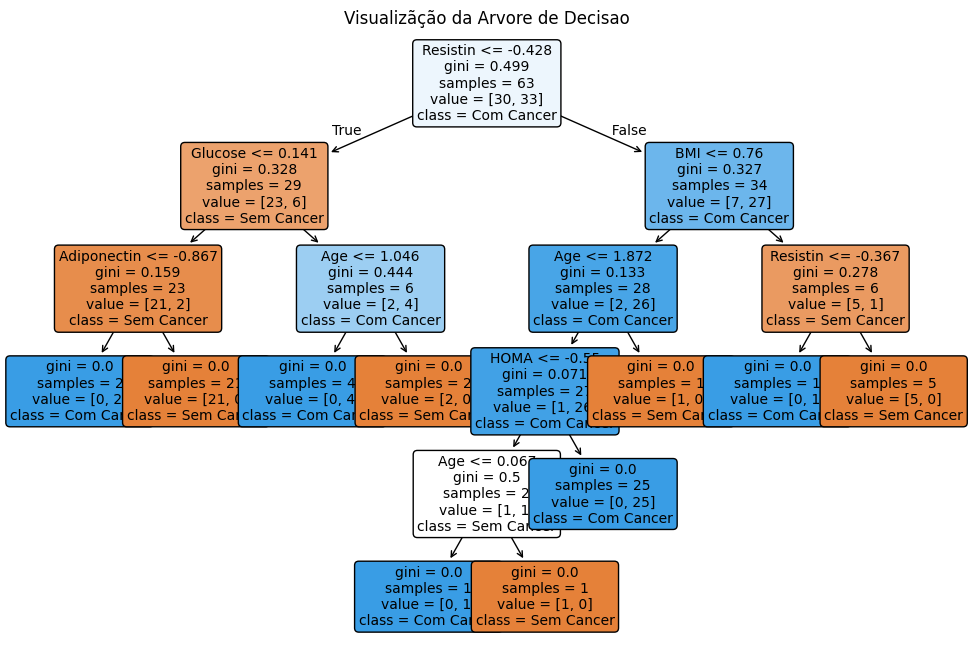

In [359]:
plt.figure(figsize=(12,8))
plot_tree(modelo,
          feature_names=X_dados.columns,
          class_names=['Sem Cancer', 'Com Cancer'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Visualizãção da Arvore de Decisao')
plt.show()

### 5.5 Avaliação de desempenho

#### 5.5.1 Matriz de Confusão (Confusion Matrix)

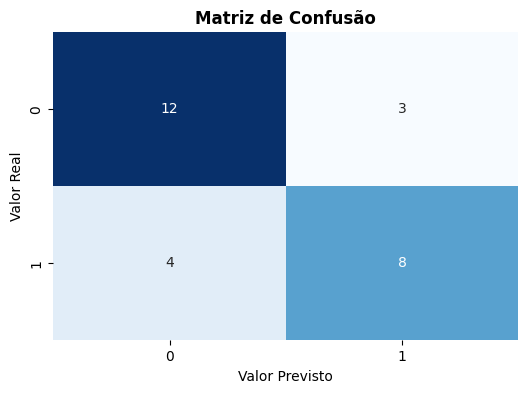

In [360]:
plt.figure(figsize=(6,4))
matrix_conf = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix_conf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão', fontsize=12, fontweight='bold')
plt.xlabel('Valor Previsto', fontsize=10)
plt.ylabel('Valor Real', fontsize=10)
plt.show()

#### 5.5.2 Relatório de Classificação (Classification Report)

In [361]:
acuracia = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acuracia * 100:.0f}\n')
print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Acurácia: 74

              precision    recall  f1-score   support

           1       0.75      0.80      0.77        15
           2       0.73      0.67      0.70        12

    accuracy                           0.74        27
   macro avg       0.74      0.73      0.73        27
weighted avg       0.74      0.74      0.74        27

              precision    recall  f1-score   support

           1       0.75      0.80      0.77        15
           2       0.73      0.67      0.70        12

    accuracy                           0.74        27
   macro avg       0.74      0.73      0.73        27
weighted avg       0.74      0.74      0.74        27



### 5.6 Variável que possui a maior correlação com a 'Classification' (Target)

In [362]:
# Calcula a matriz de correlação de todas as colunas
matriz_correlacao = df.corr()

# Exibe a correlação de todas as variáveis especificamente com a coluna 'Classification',
# ordenando da maior para a menor (em valor absoluto ou direto)
correlacao_target = matriz_correlacao['Classification'].sort_values(ascending=False)

print(correlacao_target)

Classification    1.000000
Glucose           0.384315
HOMA              0.284012
Insulin           0.276804
Resistin          0.227310
MCP.1             0.091381
Leptin           -0.001078
Adiponectin      -0.019490
Age              -0.043555
BMI              -0.132586
Name: Classification, dtype: float64


### 